In [1]:
#!/usr/bin/env python3
"""
Plot distribution of uphill work (segment_work) for multiple cities.

Author: Federico Bellisardi
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path


In [2]:

MM_PER_INCH = 25.4
def mm_to_in(mm): return mm / MM_PER_INCH

mpl.rcParams.update({
    "figure.figsize": (mm_to_in(90), mm_to_in(60)),  # single-column
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.01,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 0.9,
    "figure.constrained_layout.use": True,
})

CITY_NAME_MAP = {
    "barcelone": "Barcelona",
    "rome": "Rome",
    "madrid": "Madrid",
    "boston": "Boston",
    "santiago": "Santiago",
}


In [3]:

def load_segment_work(city: str) -> pd.Series:
    file_path = Path(f"/home/fbellisardi/code/topolity/data/data_processed/{city}/graphs/arc_work_segments_original.csv")
    if not file_path.exists():
        print(f"[WARNING] File not found for {city}: {file_path}")
        return pd.Series(dtype=float)
    df = pd.read_csv(file_path, usecols=["segment_work"])
    return df["segment_work"]


In [4]:

def plot_work_distribution(city_data: dict, outfile: str = None, log_scale: bool = False) -> None:
    fig, ax = plt.subplots()

    all_values = np.concatenate([v.values for v in city_data.values() if len(v) > 0])

    if log_scale:
        all_values = all_values[all_values > 0]
        bins = np.logspace(np.log10(all_values.min()), np.log10(np.percentile(all_values, 100)), 40)
    else:
        bins = np.linspace(0, np.percentile(all_values, 100), 40)

    for city, values in city_data.items():
        if len(values) == 0:
            continue
        vals = values[values > 0] if log_scale else values
        label = CITY_NAME_MAP.get(city, city.capitalize())

        ax.hist(vals, bins=bins, alpha=0.35, density=False, label=label)

        try:
            from scipy.stats import gaussian_kde
            kde_vals = np.log(vals) if log_scale else vals
            kde = gaussian_kde(kde_vals)
            x = np.linspace(np.log(bins[0]), np.log(bins[-1]), 300) if log_scale else np.linspace(bins[0], bins[-1], 300)
            y = kde(x)
            if log_scale:
                x = np.exp(x)
            ax.plot(x, y, lw=1.2)
        except ImportError:
            pass  # KDE optional

    if log_scale:
        ax.set_xscale("log")
        ax.set_xlabel("Segment uphill work (log scale)")
    else:
        ax.set_xlabel("Segment uphill work")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    ax.grid(True, lw=0.3, alpha=0.25, which="both")

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile)
        print(f"[INFO] Figure saved to {outfile}")


In [5]:

def _common_bins(values: np.ndarray, log_scale: bool, nbins: int = 40) -> np.ndarray:
    if log_scale:
        values = values[values > 0]
        lo, hi = values.min(), np.percentile(values, 99)
        return np.logspace(np.log10(lo), np.log10(hi), nbins)
    else:
        lo, hi = 0.0, np.percentile(values, 99)
        return np.linspace(lo, hi, nbins)

def plot_work_distribution_overall(city_data: dict, outfile: str = None, log_scale: bool = False) -> None:
    all_values = np.concatenate([v.values for v in city_data.values() if len(v) > 0])
    if log_scale:
        all_values = all_values[all_values > 0]
    if all_values.size == 0:
        print("[WARNING] No data to plot.")
        return

    bins = _common_bins(all_values, log_scale)

    fig, ax = plt.subplots()

    ax.hist(all_values, bins=bins, alpha=0.8, density=False, edgecolor="none")

    if log_scale:
        ax.set_xscale("log")
        ax.set_xlabel("Segment uphill work (log scale)")
    else:
        ax.set_xlabel("Segment uphill work")
    ax.set_ylabel("Frequency")
    ax.grid(True, lw=0.3, alpha=0.25, which="both")

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile)
        print(f"[INFO] Figure saved to {outfile}")


In [21]:

def plot_cumulative_distribution(city_data: dict, outfile: str = None, log_scale: bool = False) -> None:
    """
    Plot cumulative distribution curves showing the fraction of segments 
    with work less than or equal to a given value.
    """
    fig, ax = plt.subplots()

    for city, values in city_data.items():
        if len(values) == 0:
            continue
        
        label = CITY_NAME_MAP.get(city, city.capitalize())
        
        # Remove zero and negative values if log scale
        vals = values[values > 0].values if log_scale else values.values
        
        # Sort values in ascending order
        sorted_vals = np.sort(vals)
        
        # Calculate cumulative probability
        y = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        
        ax.plot(sorted_vals, y, lw=1.2, label=label)
    
    if log_scale:
        ax.set_xscale("log")
        ax.set_xlabel("Segment uphill work (log scale)")
    else:
        ax.set_xlabel("Segment uphill work")
    
    ax.set_ylabel("Cumulative probability")
    ax.legend(frameon=False, loc='lower right')
    ax.grid(True, lw=0.3, alpha=0.25, which="both" if log_scale else "major")
    ax.set_ylim(0, 1)
    
    # Keep only left and bottom spines visible (Nature style)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)
    
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile)
        print(f"[INFO] Cumulative distribution curve saved to {outfile}")


/tmp/ipykernel_2203884/1137838840.py:41: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


[INFO] Figure saved to /home/fbellisardi/code/topolity/paper/images/test_work_distribution_log.pdf


/tmp/ipykernel_2203884/1338038201.py:42: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


[INFO] Cumulative distribution curve saved to /home/fbellisardi/code/topolity/paper/images/gravity_work_analysis/cum_distribution.pdf


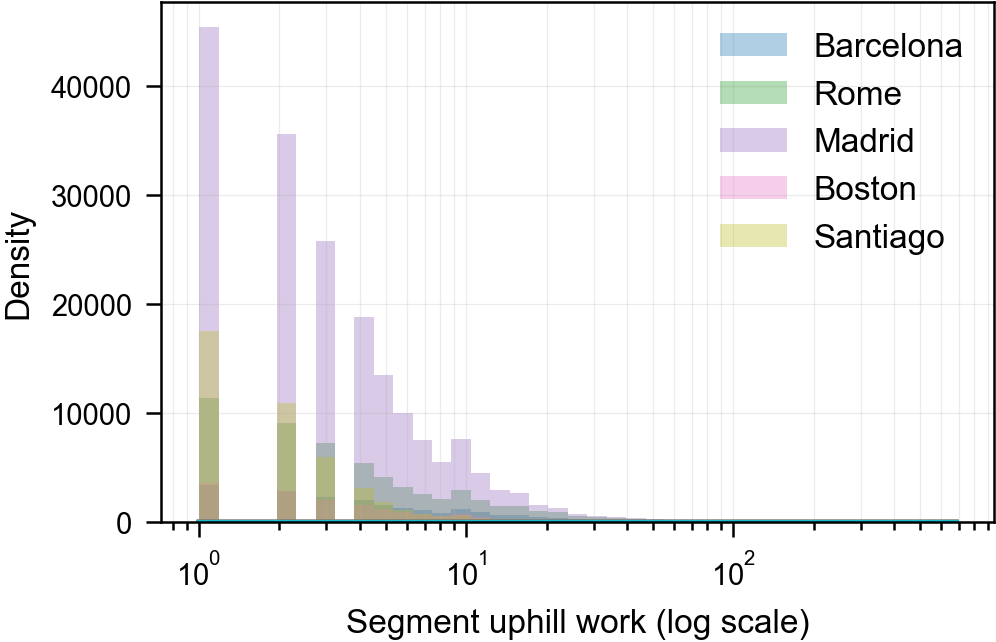

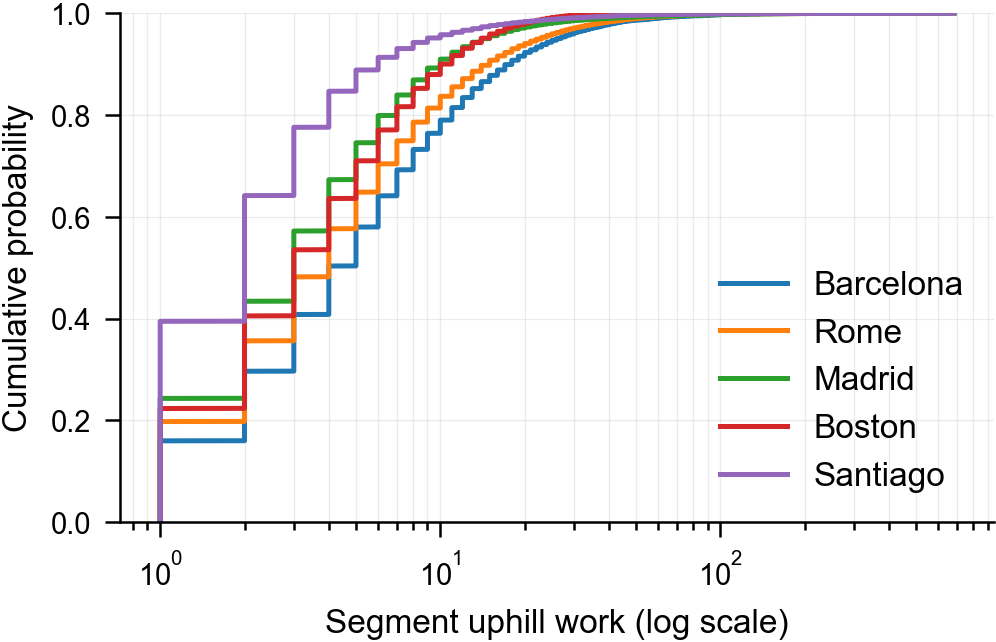

In [ ]:
if __name__ == "__main__":
    cities = ["barcelone", "rome", "madrid", "boston", "santiago"]

    city_data = {city: load_segment_work(city) for city in cities}

    # plot_work_distribution(city_data, outfile="/home/fbellisardi/code/topolity/paper/images/test_work_distribution_linear.pdf", log_scale=False)
    plot_work_distribution(city_data, outfile="/home/fbellisardi/code/topolity/paper/images/test_work_distribution_log.pdf", log_scale=True)
    plot_cumulative_distribution(city_data, outfile="/home/fbellisardi/code/topolity/paper/images/gravity_work_analysis/cum_distribution.pdf", log_scale=True)

    # plot_work_distribution_overall(city_data, outfile="/home/fbellisardi/code/topolity/paper/images/test_work_distribution_overall_linear.pdf", log_scale=False)
    # plot_work_distribution_overall(city_data, outfile="/home/fbellisardi/code/topolity/paper/images/test_work_distribution_overall_log.pdf", log_scale=True)
